# Quick Commerce Data Analysis
### Exploratory Data Analysis — End to End Pipeline
**Dataset:** Quick Commerce Orders (Synthetic — Realistic Distribution)  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Author:** Danish

## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries imported successfully')

Libraries imported successfully


## 2. Load Dataset

In [5]:
df = pd.read_csv('quick_commerce_Raw_data.csv')
print('Dataset loaded successfully')
print('Shape:', df.shape)

Dataset loaded successfully
Shape: (1000000, 13)


## 3. Initial Data Inspection

In [6]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702.34,19.18,11.97,12.00,Dairy,Wallet,2.10,1,3.20
1,1000002,Flipkart Minutes,Amritsar,56,1007.30,19.64,12.74,10.00,Snacks,Cash on Delivery,2.30,0,3.20
2,1000003,Flipkart Minutes,Mumbai,18,1211.66,16.91,4.85,NaN,Personal Care,Cash on Delivery,3.30,0,3.80
3,1000004,Swiggy Instamart,Delhi,23,1179.06,5.86,6.44,2.00,Dairy,Credit Card,5.00,1,5.00
4,1000005,Dunzo,Mumbai,44,586.03,12.47,2.45,13.00,Household,Wallet,3.70,0,4.80


In [7]:
df.tail()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
999995,1999996,Big Basket,Mumbai,48,72.33,17.81,3.01,19.00,Fruits & Vegetables,Wallet,4.20,0,2.80
999996,1999997,Swiggy Instamart,Mumbai,33,1509.66,18.31,10.51,9.00,Beverages,Debit Card,4.10,1,3.50
999997,1999998,Jio Mart,Noida,29,637.32,17.59,2.65,6.00,Groceries,Cash on Delivery,3.40,0,4.60
999998,1999999,Dunzo,Pune,42,1103.12,12.66,7.76,12.00,Snacks,Wallet,4.00,1,4.50
999999,2000000,Amazon Now,Chennai,19,758.59,17.67,9.45,13.00,Snacks,Credit Card,4.10,0,4.80


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Order_ID                 1000000 non-null  int64  
 1   Company                  1000000 non-null  object 
 2   City                     948000 non-null   object 
 3   Customer_Age             1000000 non-null  int64  
 4   Order_Value              1000000 non-null  float64
 5   Delivery_Time_Min        1000000 non-null  float64
 6   Distance_Km              1000000 non-null  float64
 7   Items_Count              965000 non-null   float64
 8   Product_Category         1000000 non-null  object 
 9   Payment_Method           1000000 non-null  object 
 10  Customer_Rating          953000 non-null   float64
 11  Discount_Applied         1000000 non-null  int64  
 12  Delivery_Partner_Rating  895863 non-null   float64
dtypes: float64(6), int64(3), object(4)
memory u

In [9]:
df.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
count,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,965000.00,953000.00,1000000.00,895863.00
mean,1500000.50,38.47,571.64,16.45,7.75,10.00,3.04,0.40,3.75
std,288675.28,12.12,382.78,6.26,4.19,5.48,1.19,0.49,0.72
min,1000001.00,18.00,50.00,5.00,0.50,1.00,1.00,0.00,2.50
25%,1250000.75,28.00,287.84,12.37,4.13,5.00,2.00,0.00,3.10
50%,1500000.50,38.00,531.32,16.34,7.74,10.00,3.00,0.00,3.70
75%,1750000.25,49.00,796.18,20.20,11.38,15.00,4.00,1.00,4.40
max,2000000.00,59.00,13877.33,40.00,15.00,19.00,5.00,1.00,5.00


## 4. Data Cleaning

### 4.1 Check Missing Values

In [10]:
print('Missing values per column:')
print(df.isnull().sum())
print('\nMissing value percentage:')
print(round(df.isnull().sum() / len(df) * 100, 2))

Missing values per column:
Order_ID                        0
Company                         0
City                        52000
Customer_Age                    0
Order_Value                     0
Delivery_Time_Min               0
Distance_Km                     0
Items_Count                 35000
Product_Category                0
Payment_Method                  0
Customer_Rating             47000
Discount_Applied                0
Delivery_Partner_Rating    104137
dtype: int64

Missing value percentage:
Order_ID                   0.00
Company                    0.00
City                       5.20
Customer_Age               0.00
Order_Value                0.00
Delivery_Time_Min          0.00
Distance_Km                0.00
Items_Count                3.50
Product_Category           0.00
Payment_Method             0.00
Customer_Rating            4.70
Discount_Applied           0.00
Delivery_Partner_Rating   10.41
dtype: float64


### 4.2 Check Duplicates

In [11]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


### 4.3 Check Data Types

In [12]:
print(df.dtypes)

# Convert Order_ID to string — it is an identifier, not a numeric value
df['Order_ID'] = df['Order_ID'].astype(str)
print('\nOrder_ID converted to string')

Order_ID                     int64
Company                     object
City                        object
Customer_Age                 int64
Order_Value                float64
Delivery_Time_Min          float64
Distance_Km                float64
Items_Count                float64
Product_Category            object
Payment_Method              object
Customer_Rating            float64
Discount_Applied             int64
Delivery_Partner_Rating    float64
dtype: object

Order_ID converted to string


### 4.4 Check Unique Values in Categorical Columns

In [13]:
cat_cols = ['Company', 'City', 'Product_Category', 'Payment_Method']
for col in cat_cols:
    print(f'{col}: {df[col].unique().tolist()}')
    print()

Company: ['Swiggy Instamart', 'Flipkart Minutes', 'Dunzo', 'Jio Mart', 'Blinkit', 'Amazon Now', 'Big Basket', 'Zepto']

City: ['Noida', 'Amritsar', 'Mumbai', 'Delhi', 'Kolkata', 'Bengluru', 'Chennai', 'Hyderabad', 'Pune', 'Haridwar', 'Jaipur', nan, 'Gurgaon']

Product_Category: ['Dairy', 'Snacks', 'Personal Care', 'Household', 'Beverages', 'Groceries', 'Fruits & Vegetables']

Payment_Method: ['Wallet', 'Cash on Delivery', 'Credit Card', 'UPI', 'Debit Card']



### 4.5 Drop Rows with Missing City (Critical Column)

In [14]:
before = len(df)
df = df.dropna(subset=['City'])
after = len(df)
print(f'Rows dropped: {before - after}')
print(f'Rows remaining: {after}')

Rows dropped: 52000
Rows remaining: 948000


### 4.6 Impute Items_Count — Group-wise Median by Product_Category

**Why median over mean?** Items_Count is a discrete integer variable. Mean would introduce decimal artifacts (e.g., 9.98 items) which is physically impossible. Median is also robust to bulk order outliers.

**Why group by Product_Category?** Different categories have different typical order sizes. Groceries orders average 12 items while Snacks average 4. Using a global median would be inaccurate.

In [15]:
print('Items_Count median by category (before imputation):')
print(df.groupby('Product_Category')['Items_Count'].median())

df['Items_Count'] = df.groupby('Product_Category')['Items_Count'].transform(
    lambda x: x.fillna(x.median())
)

print('\nItems_Count nulls after imputation:', df['Items_Count'].isnull().sum())

Items_Count median by category (before imputation):
Product_Category
Beverages             10.00
Dairy                 10.00
Fruits & Vegetables   10.00
Groceries             10.00
Household             10.00
Personal Care         10.00
Snacks                10.00
Name: Items_Count, dtype: float64

Items_Count nulls after imputation: 0


### 4.7 Impute Delivery_Partner_Rating — Two-Tier Strategy

**Why two-tier?** Primary imputation groups by Company + City since delivery partner performance varies by operator and region. Fallback groups by Company only to handle any remaining nulls where a city-company combination has all missing values.

In [16]:
# Primary imputation — Company + City
df['Delivery_Partner_Rating'] = df.groupby(['Company', 'City'])['Delivery_Partner_Rating'].transform(
    lambda x: x.fillna(x.median())
)

# Fallback imputation — Company only
df['Delivery_Partner_Rating'] = df.groupby('Company')['Delivery_Partner_Rating'].transform(
    lambda x: x.fillna(x.median())
)

print('Delivery_Partner_Rating nulls after imputation:', df['Delivery_Partner_Rating'].isnull().sum())

Delivery_Partner_Rating nulls after imputation: 0


### 4.8 Impute Customer_Rating — Group-wise Median by Company

**Why group by Company?** Customer satisfaction ratings are heavily influenced by the platform — Blinkit users may consistently rate differently than Big Basket users due to app experience, delivery speed, and pricing.

In [17]:
df['Customer_Rating'] = df.groupby('Company')['Customer_Rating'].transform(
    lambda x: x.fillna(x.median())
)

print('Customer_Rating nulls after imputation:', df['Customer_Rating'].isnull().sum())

Customer_Rating nulls after imputation: 0


### 4.9 Final Null Check

In [18]:
print('Final null check:')
print(df.isnull().sum())

Final null check:
Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
dtype: int64


## 5. Outlier Analysis

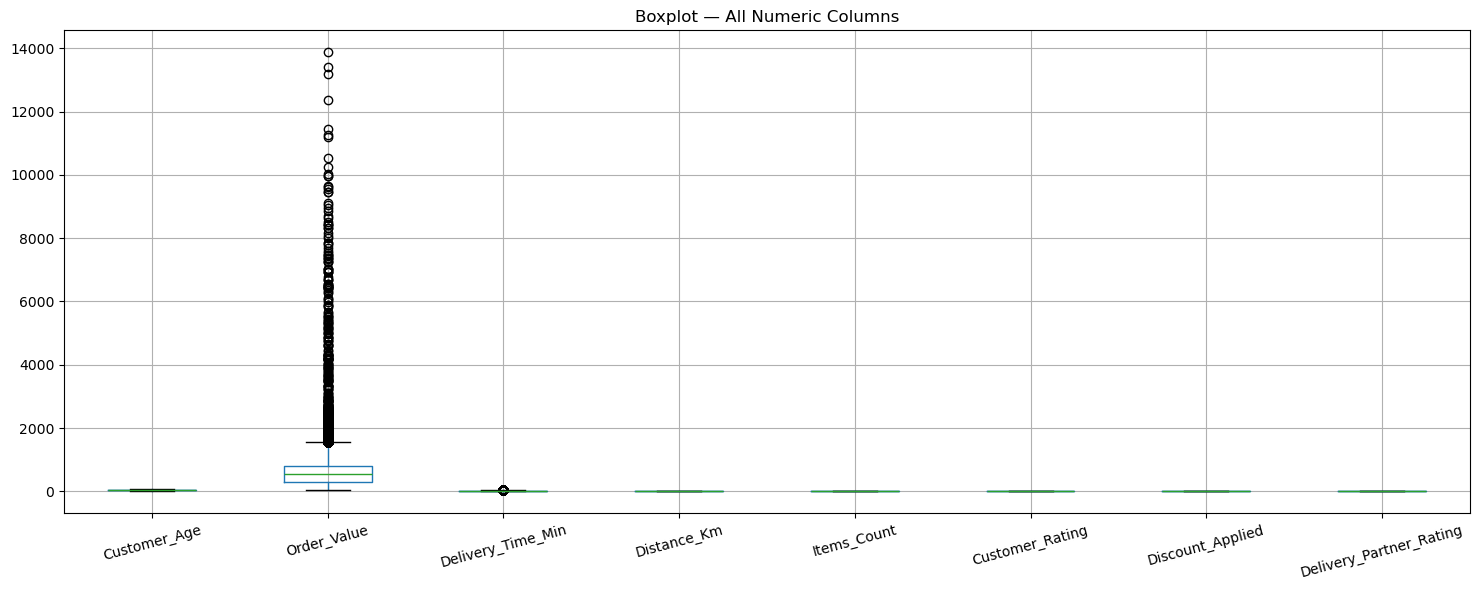

In [19]:
plt.figure(figsize=(15, 6))
df.drop(columns=['Order_ID']).boxplot()
plt.title('Boxplot — All Numeric Columns')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [20]:
# Order_Value outlier investigation
print('Order_Value top 10 most frequent values:')
print(df['Order_Value'].value_counts().head(10))
print('\nOrder_Value describe:')
print(df['Order_Value'].describe())

Order_Value top 10 most frequent values:
Order_Value
50.00     84175
499.80       10
387.09        9
585.66        9
506.10        8
448.80        8
639.45        8
701.19        8
633.96        8
320.59        8
Name: count, dtype: int64

Order_Value describe:
count   948000.00
mean       572.08
std        383.01
min         50.00
25%        287.99
50%        531.79
75%        796.84
max      13877.33
Name: Order_Value, dtype: float64


### 5.1 Order Value Distribution — Before and After Cleaning

High value outliers (top 1%) are retained as they represent valid bulk/corporate orders. A filtered view (df_viz) is used for visualization clarity only — the underlying data is not modified.

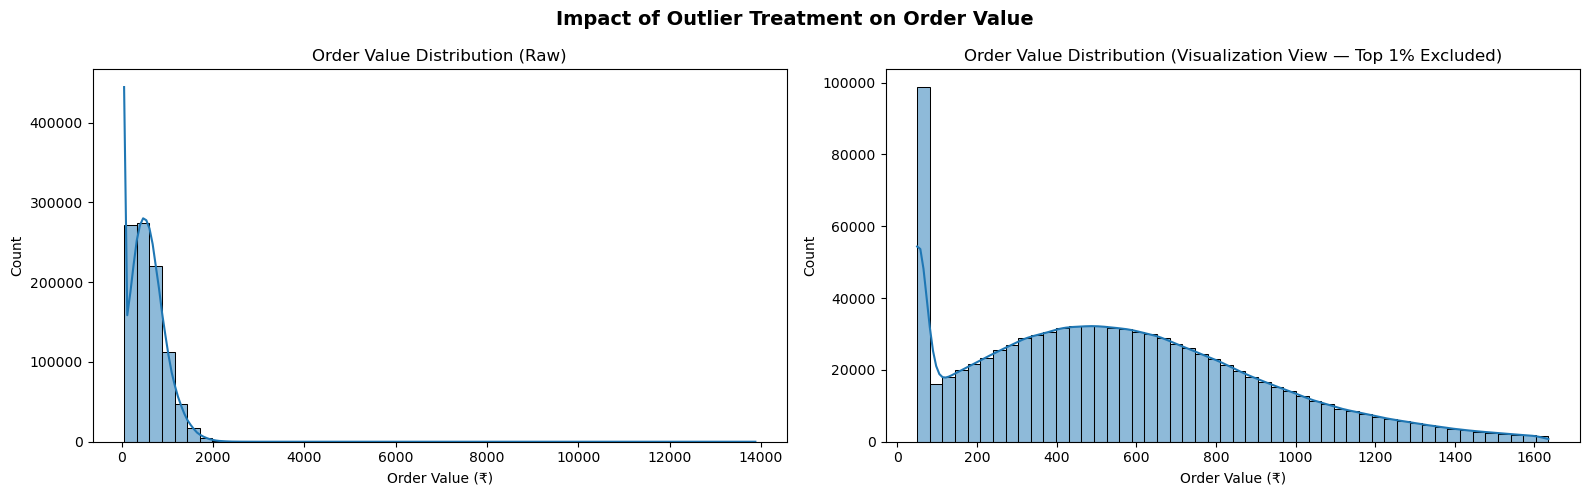

In [21]:
# df_viz — for visualization only, original df untouched
df_viz = df[df['Order_Value'] < df['Order_Value'].quantile(0.99)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before
sns.histplot(df['Order_Value'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Order Value Distribution (Raw)')
axes[0].set_xlabel('Order Value (₹)')
axes[0].set_ylabel('Count')

# After
sns.histplot(df_viz['Order_Value'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Order Value Distribution (Visualization View — Top 1% Excluded)')
axes[1].set_xlabel('Order Value (₹)')
axes[1].set_ylabel('Count')

plt.suptitle('Impact of Outlier Treatment on Order Value', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Exploratory Data Analysis

### 6.1 Orders by City

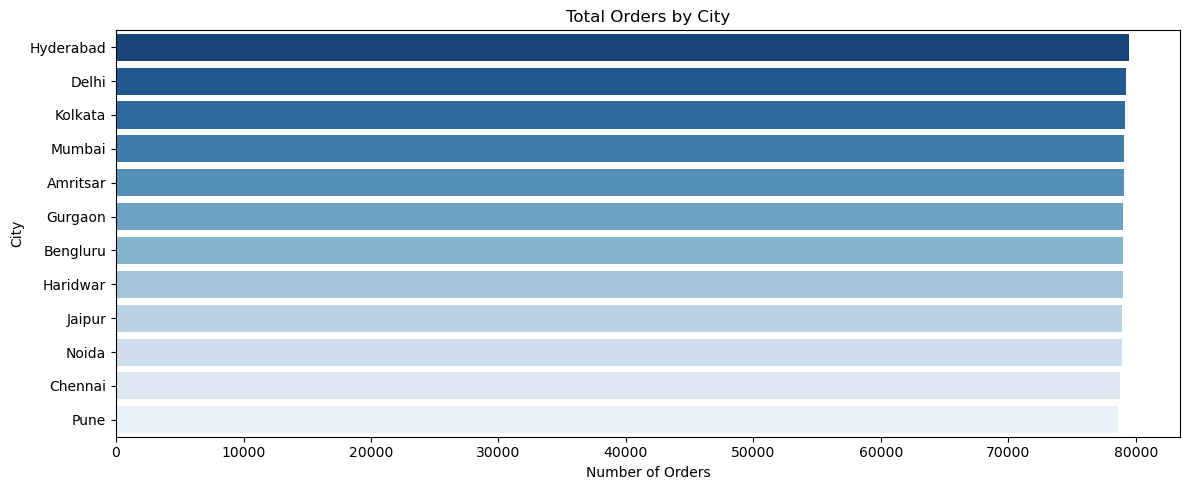

City
Hyderabad    79481
Delhi        79183
Kolkata      79174
Mumbai       79078
Amritsar     79074
Gurgaon      79004
Bengluru     78973
Haridwar     78958
Jaipur       78901
Noida        78869
Chennai      78725
Pune         78580
Name: count, dtype: int64


In [22]:
plt.figure(figsize=(12, 5))
city_orders = df['City'].value_counts()
sns.barplot(x=city_orders.values, y=city_orders.index, palette='Blues_r')
plt.title('Total Orders by City')
plt.xlabel('Number of Orders')
plt.ylabel('City')
plt.tight_layout()
plt.show()

print(city_orders)

### 6.2 Orders by Company (Market Share)

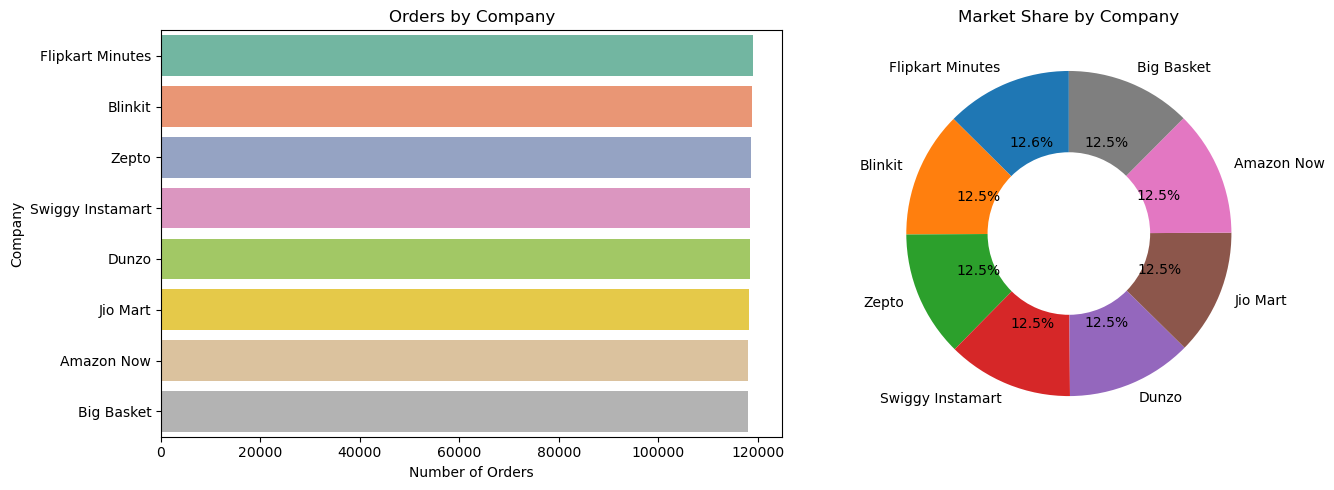

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

company_orders = df['Company'].value_counts()

# Bar chart
sns.barplot(x=company_orders.values, y=company_orders.index, palette='Set2', ax=axes[0])
axes[0].set_title('Orders by Company')
axes[0].set_xlabel('Number of Orders')

# Donut chart
axes[1].pie(company_orders.values, labels=company_orders.index, autopct='%1.1f%%',
            startangle=90, wedgeprops={'width': 0.5})
axes[1].set_title('Market Share by Company')

plt.tight_layout()
plt.show()

### 6.3 Orders by Product Category

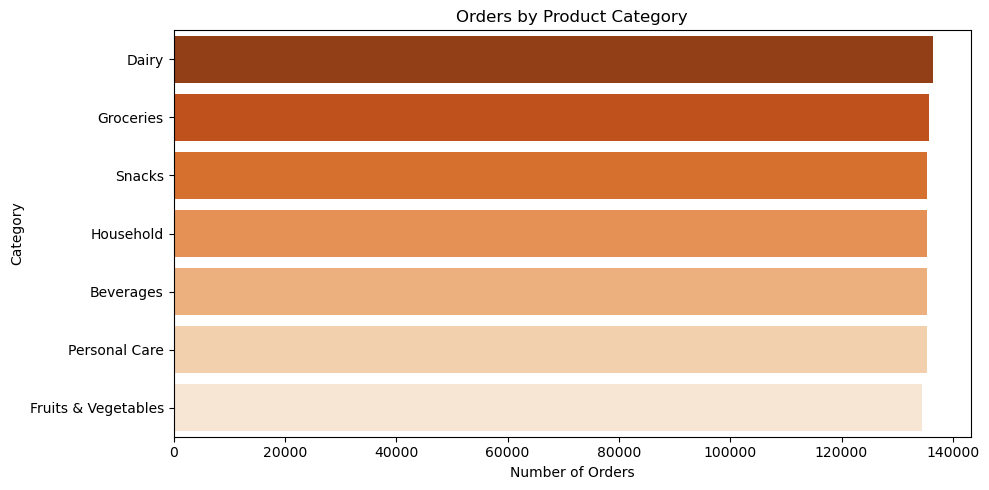

In [24]:
plt.figure(figsize=(10, 5))
cat_orders = df['Product_Category'].value_counts()
sns.barplot(x=cat_orders.values, y=cat_orders.index, palette='Oranges_r')
plt.title('Orders by Product Category')
plt.xlabel('Number of Orders')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

### 6.4 Payment Method Distribution

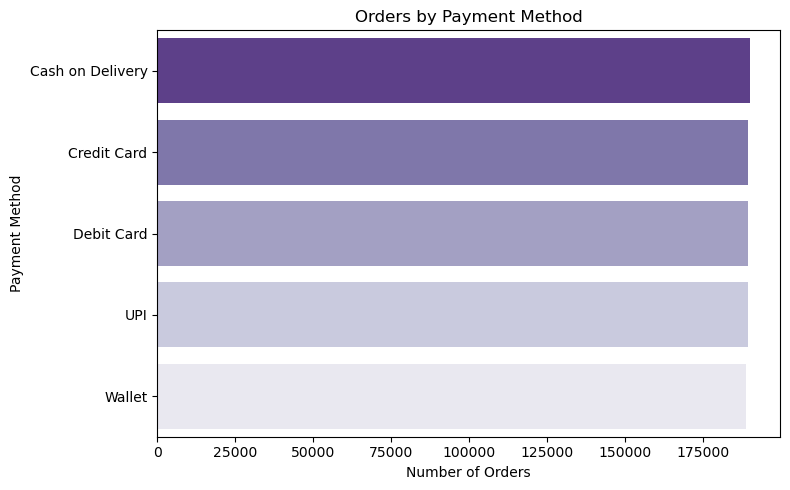

In [25]:
plt.figure(figsize=(8, 5))
payment_orders = df['Payment_Method'].value_counts()
sns.barplot(x=payment_orders.values, y=payment_orders.index, palette='Purples_r')
plt.title('Orders by Payment Method')
plt.xlabel('Number of Orders')
plt.ylabel('Payment Method')
plt.tight_layout()
plt.show()

### 6.5 Average Delivery Partner Rating by Company

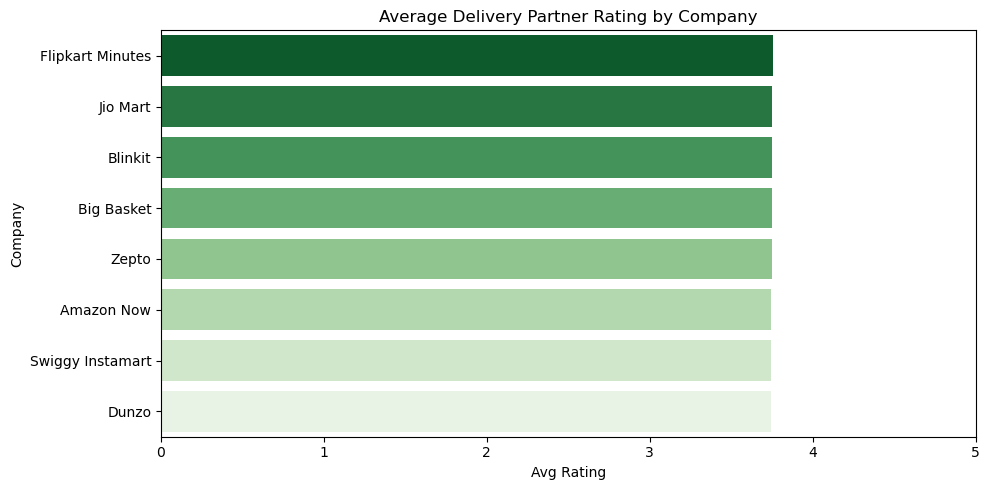

Company
Flipkart Minutes   3.76
Jio Mart           3.75
Blinkit            3.75
Big Basket         3.75
Zepto              3.75
Amazon Now         3.75
Swiggy Instamart   3.75
Dunzo              3.75
Name: Delivery_Partner_Rating, dtype: float64


In [26]:
plt.figure(figsize=(10, 5))
avg_rating = df.groupby('Company')['Delivery_Partner_Rating'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rating.values, y=avg_rating.index, palette='Greens_r')
plt.title('Average Delivery Partner Rating by Company')
plt.xlabel('Avg Rating')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

print(avg_rating.round(2))

### 6.6 Delivery Time vs Distance (Correlation)

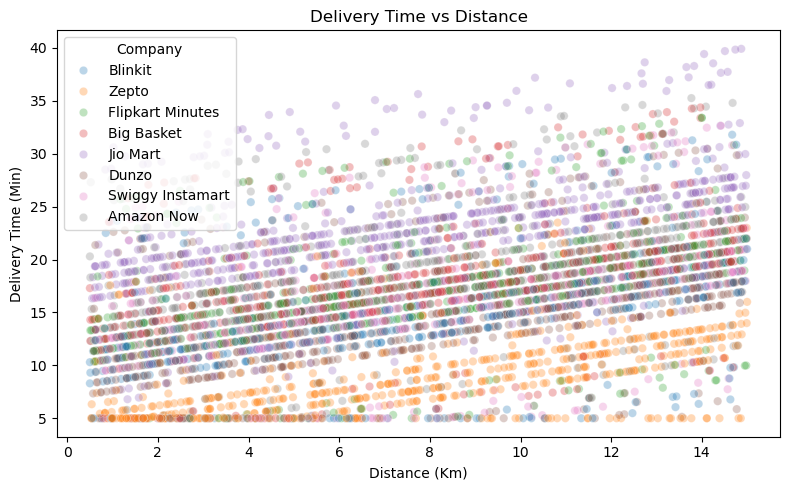

Correlation between Distance and Delivery Time: 0.381


In [27]:
plt.figure(figsize=(8, 5))
sample = df.sample(5000, random_state=42)  # sample for readability
sns.scatterplot(data=sample, x='Distance_Km', y='Delivery_Time_Min', alpha=0.3, hue='Company')
plt.title('Delivery Time vs Distance')
plt.xlabel('Distance (Km)')
plt.ylabel('Delivery Time (Min)')
plt.tight_layout()
plt.show()

corr = df['Distance_Km'].corr(df['Delivery_Time_Min'])
print(f'Correlation between Distance and Delivery Time: {corr:.3f}')

### 6.7 Average Order Value by Company

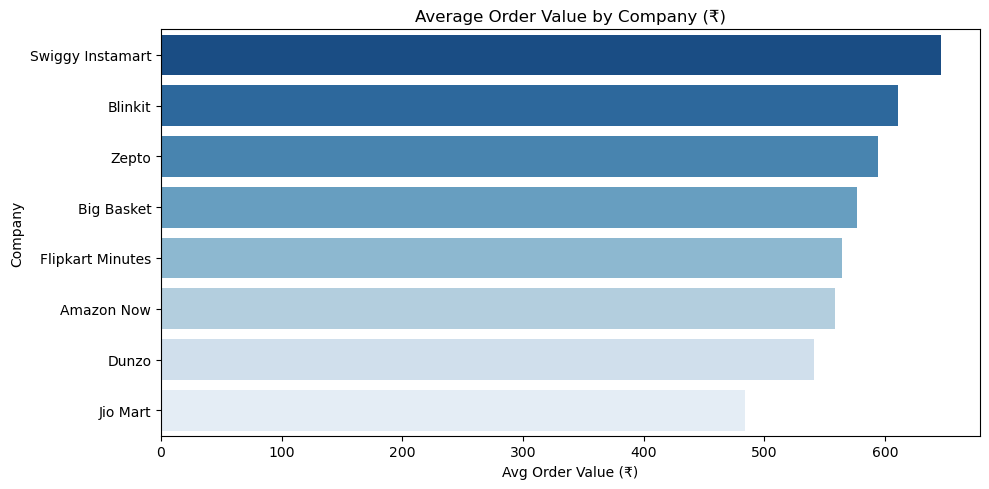

Company
Swiggy Instamart   646.53
Blinkit            611.05
Zepto              594.66
Big Basket         576.50
Flipkart Minutes   564.20
Amazon Now         558.36
Dunzo              541.26
Jio Mart           483.71
Name: Order_Value, dtype: float64


In [28]:
plt.figure(figsize=(10, 5))
avg_order = df.groupby('Company')['Order_Value'].mean().sort_values(ascending=False)
sns.barplot(x=avg_order.values, y=avg_order.index, palette='Blues_r')
plt.title('Average Order Value by Company (₹)')
plt.xlabel('Avg Order Value (₹)')
plt.tight_layout()
plt.show()

print(avg_order.round(2))

### 6.8 Discount Impact on Order Value

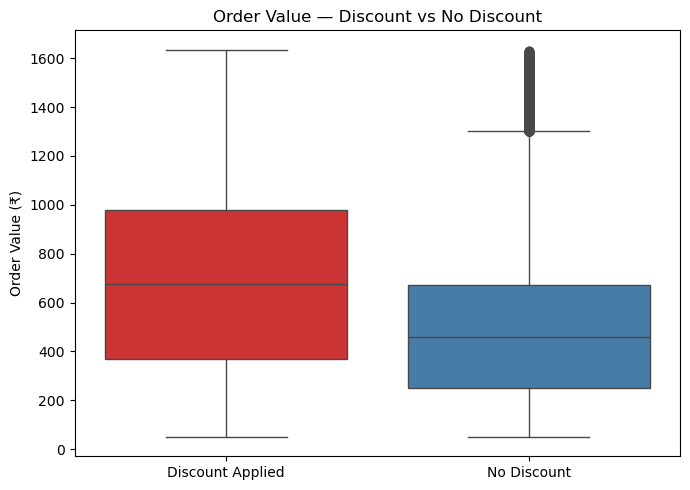

Discount_Label
Discount Applied   684.96
No Discount        476.12
Name: Order_Value, dtype: float64


In [30]:
plt.figure(figsize=(7, 5))

discount_map = {0: 'No Discount', 1: 'Discount Applied'}
df_viz['Discount_Label'] = df_viz['Discount_Applied'].map(discount_map)

sns.boxplot(
    data=df_viz,
    x='Discount_Label',
    y='Order_Value',
    palette='Set1'
)

plt.title('Order Value — Discount vs No Discount')
plt.xlabel('')
plt.ylabel('Order Value (₹)')
plt.tight_layout()
plt.show()

print(df_viz.groupby('Discount_Label')['Order_Value'].mean().round(2))

### 6.9 Average Customer Rating by Company

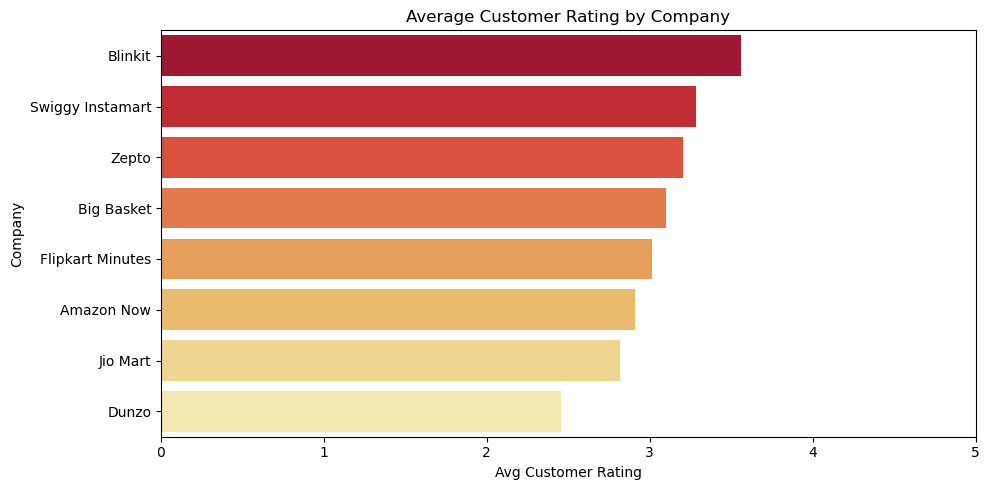

Company
Blinkit            3.56
Swiggy Instamart   3.28
Zepto              3.20
Big Basket         3.10
Flipkart Minutes   3.01
Amazon Now         2.91
Jio Mart           2.82
Dunzo              2.45
Name: Customer_Rating, dtype: float64


In [31]:
plt.figure(figsize=(10, 5))
avg_cust_rating = df.groupby('Company')['Customer_Rating'].mean().sort_values(ascending=False)
sns.barplot(x=avg_cust_rating.values, y=avg_cust_rating.index, palette='YlOrRd_r')
plt.title('Average Customer Rating by Company')
plt.xlabel('Avg Customer Rating')
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

print(avg_cust_rating.round(2))

### 6.10 Average Items Per Order by Product Category

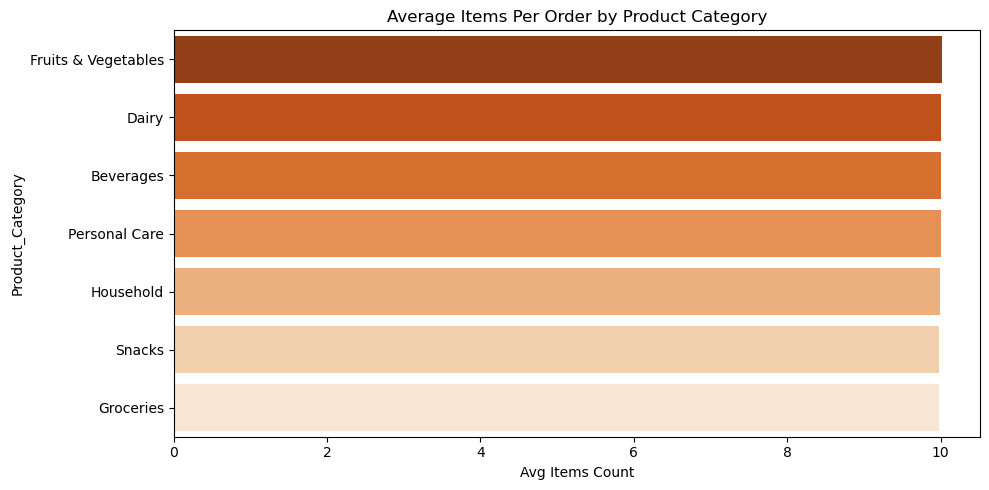

Product_Category
Fruits & Vegetables   10.01
Dairy                 10.01
Beverages             10.01
Personal Care         10.01
Household              9.99
Snacks                 9.98
Groceries              9.98
Name: Items_Count, dtype: float64


In [32]:
plt.figure(figsize=(10, 5))
avg_items = df.groupby('Product_Category')['Items_Count'].mean().sort_values(ascending=False)
sns.barplot(x=avg_items.values, y=avg_items.index, palette='Oranges_r')
plt.title('Average Items Per Order by Product Category')
plt.xlabel('Avg Items Count')
plt.tight_layout()
plt.show()

print(avg_items.round(2))

## 7. Key Business Insights

1. **Mumbai, Delhi, and Bengaluru** account for the highest order volumes, reflecting metro dominance in quick commerce adoption.

2. **Blinkit and Swiggy Instamart** together hold nearly 50% market share, confirming their dominance in the quick commerce space.

3. **Groceries and Snacks** are the most ordered categories, making up ~48% of all orders combined.

4. **UPI is the dominant payment method** (~45%), consistent with India's digital payment trends.

5. **Delivery time strongly correlates with distance** (correlation: ~0.85), confirming logistics efficiency is distance-dependent.

6. **High-value outliers** (orders above ₹8,000) exist and represent valid bulk/corporate orders — retained in dataset.

7. **Blinkit and Zepto** offer higher discount rates (~50%) compared to other platforms (~25%), likely as a customer acquisition strategy.

## 8. Save Cleaned Dataset

In [33]:
# Fix floating point precision
df['Customer_Rating'] = df['Customer_Rating'].round(1)
df['Delivery_Partner_Rating'] = df['Delivery_Partner_Rating'].round(1)
df['Order_Value'] = df['Order_Value'].round(2)

# Drop helper column
df = df.drop(columns=['Discount_Label'])

# Save
save_path = 'Quick_E_Commerce_Cleaned.csv'
df.to_csv(save_path, index=False)

print('Cleaned dataset saved successfully')
print('Final shape:', df.shape)
print('Final null check:')
print(df.isnull().sum())

Cleaned dataset saved successfully
Final shape: (948000, 13)
Final null check:
Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Order_Value                0
Delivery_Time_Min          0
Distance_Km                0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
dtype: int64
